# Step 1 — Install Dependencies

In [1]:
!pip install -q transformers datasets scikit-learn pandas torch accelerate

# Step 2 — Imports

In [2]:
import pandas as pd
import numpy as np
import torch
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset, Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline
)
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from collections import Counter

print(f"PyTorch version : {torch.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device      : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.10.0+cu128
GPU available   : True
GPU device      : Tesla T4


#Step 3 — Load Dataset

In [3]:
data_set = load_dataset("Tobi-Bueck/customer-support-tickets")
print(data_set)

README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
        num_rows: 61765
    })
})


In [4]:
# Inspect the first few rows and column names
split_name = list(data_set.keys())[0]
df_raw = data_set[split_name].to_pandas()

print(f"Split used      : '{split_name}'")
print(f"Shape           : {df_raw.shape}")
print(f"Columns         : {df_raw.columns.tolist()}")
df_raw.head(5)

Split used      : 'train'
Shape           : (61765, 16)
Columns         : ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


# Step 4 — Explore & Map Labels

In [5]:
# ── Identify text and label columns ──────────────────────────────────────────
# Adjust these names if the dataset columns differ after you print them above
TEXT_COL  = 'subject'    # primary text column
LABEL_COL = 'queue'      # raw category column

# Fallback: use first object columns if the above names are not present
str_cols = df_raw.select_dtypes(include='object').columns.tolist()
if TEXT_COL not in df_raw.columns:
    TEXT_COL = str_cols[0]
if LABEL_COL not in df_raw.columns:
    LABEL_COL = str_cols[1] if len(str_cols) > 1 else str_cols[0]

print(f"Text column     : {TEXT_COL}")
print(f"Label column    : {LABEL_COL}")
print()
print("Raw label distribution:")
print(df_raw[LABEL_COL].value_counts())

Text column     : subject
Label column    : queue

Raw label distribution:
queue
Technical Support                         14186
Product Support                            8960
Customer Service                           7420
IT Support                                 5725
Billing and Payments                       4874
Returns and Exchanges                      2438
Service Outages and Maintenance            1912
Sales and Pre-Sales                        1490
Human Resources                             914
General Inquiry                             668
Pets & Animals/Pet Services                 386
News                                        383
IT & Technology/Security Operations         365
Autos & Vehicles/Sales                      364
Health/Medical Services                     362
Home & Garden/Home Improvement              361
Pets & Animals/Veterinary Care              356
Health/Mental Health                        347
Business & Industrial/Manufacturing         346
Online 

In [6]:
# ── Map raw labels → 4 target categories ─────────────────────────────────────
def map_label(raw: str) -> str:
    if pd.isna(raw):
        return 'Other'
    r = str(raw).lower()
    if any(k in r for k in ['billing', 'payment', 'refund', 'invoice',
                             'charge', 'subscription', 'finance', 'bill']):
        return 'Billing'
    if any(k in r for k in ['technical', 'tech', 'login', 'password', 'error',
                             'bug', 'crash', 'access', 'account', 'software',
                             'app', 'website', 'server', 'api']):
        return 'Technical'
    if any(k in r for k in ['delivery', 'shipping', 'package', 'damaged',
                             'shipment', 'courier', 'dispatch', 'lost',
                             'delay', 'transit', 'order']):
        return 'Delivery'
    return 'Other'

df_raw['label_str'] = df_raw[LABEL_COL].apply(map_label)

print("Mapped label distribution:")
print(df_raw['label_str'].value_counts())

Mapped label distribution:
label_str
Other        40588
Technical    15664
Billing       5513
Name: count, dtype: int64


#Step 5 — Undersampling to Balance Classes

In [7]:
# Drop rows with empty text
df = df_raw[[TEXT_COL, 'label_str']].dropna(subset=[TEXT_COL])
df = df[df[TEXT_COL].str.strip() != '']
df.rename(columns={TEXT_COL: 'text', 'label_str': 'label'}, inplace=True)

# ── Undersample: keep at most target_n samples per class ─────────────────────
counts    = df['label'].value_counts()
min_count = int(counts.min())
target_n  = min(min_count, 1500)   # cap at 1500 per class for training speed

print(f"Samples per class after undersampling: {target_n}")

balanced_parts = []
for lbl in df['label'].unique():
    subset  = df[df['label'] == lbl]
    sampled = resample(subset, replace=False,
                       n_samples=min(target_n, len(subset)),
                       random_state=42)
    balanced_parts.append(sampled)

df_balanced = pd.concat(balanced_parts).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced label distribution:")
print(df_balanced['label'].value_counts())
print(f"\nTotal samples   : {len(df_balanced)}")

Samples per class after undersampling: 1500

Balanced label distribution:
label
Other        1500
Billing      1500
Technical    1500
Name: count, dtype: int64

Total samples   : 4500


#Step 6 — Encode Labels & Train / Val / Test Split

In [8]:
LABEL_LIST = sorted(df_balanced['label'].unique().tolist())
label2id   = {l: i for i, l in enumerate(LABEL_LIST)}
id2label   = {i: l for l, i in label2id.items()}
NUM_LABELS = len(LABEL_LIST)

df_balanced['label_id'] = df_balanced['label'].map(label2id)

print(f"Labels ({NUM_LABELS}): {label2id}")

# 80 / 10 / 10 split  (stratified)
df_train, df_temp = train_test_split(df_balanced, test_size=0.20,
                                     stratify=df_balanced['label_id'],
                                     random_state=42)
df_val, df_test   = train_test_split(df_temp,     test_size=0.50,
                                     stratify=df_temp['label_id'],
                                     random_state=42)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Labels (3): {'Billing': 0, 'Other': 1, 'Technical': 2}
Train: 3600 | Val: 450 | Test: 450


# Step 7 — Tokeniser & HF Datasets

In [9]:
MODEL_NAME = "distilbert-base-uncased"   # 66 M params — fastest on Colab T4

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokeniser loaded: {MODEL_NAME}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokeniser loaded: distilbert-base-uncased


In [10]:
def df_to_hf(df: pd.DataFrame) -> Dataset:
    return Dataset.from_dict({
        'text' : df['text'].tolist(),
        'label': df['label_id'].tolist()
    })

raw_datasets = DatasetDict({
    'train': df_to_hf(df_train),
    'val'  : df_to_hf(df_val),
    'test' : df_to_hf(df_test)
})
print(raw_datasets)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3600
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 450
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 450
    })
})


In [11]:
def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=128    # support tickets are short; 128 tokens is plenty
    )

tokenized = raw_datasets.map(tokenize_fn, batched=True,
                              remove_columns=['text'])
tokenized.set_format('torch')
print(tokenized)

Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3600
    })
    val: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 450
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 450
    })
})


#Step 8 — Load Pre-trained Model

In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable:,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params    : 66,955,779
Trainable params: 66,955,779


#Step 9 — Fine-Tune with HF Trainer

In [20]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds)}


data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir                  = './ticket_classifier',
    num_train_epochs            = 5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    warmup_steps                = 100,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'accuracy',
    logging_dir                 = './logs',
    logging_steps               = 50,
    report_to                   = 'none',
    fp16                        = torch.cuda.is_available(),  # AMP on GPU
    dataloader_num_workers      = 2,
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = tokenized['train'],
    eval_dataset    = tokenized['val'],
    data_collator   = data_collator,
    compute_metrics = compute_metrics,
)

print("Starting training …")
train_result = trainer.train()
print("\n Training complete!")
print(train_result.metrics)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting training …


Epoch,Training Loss,Validation Loss,Accuracy
1,0.602005,0.838869,0.608889
2,0.523398,0.856203,0.606667
3,0.442494,0.915678,0.617778
4,0.344133,0.948138,0.595556
5,0.312268,0.997438,0.597778


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



 Training complete!
{'train_runtime': 100.327, 'train_samples_per_second': 179.413, 'train_steps_per_second': 5.632, 'total_flos': 150676073804736.0, 'train_loss': 0.4421431600520041, 'epoch': 5.0}


#Step 10 — Evaluate on Test Set

In [14]:
test_results = trainer.evaluate(eval_dataset=tokenized['test'])

print("\nTest Set Results:")
for k, v in test_results.items():
    print(f"  {k:35s}: {v:.4f}" if isinstance(v, float) else f"  {k:35s}: {v}")


Test Set Results:
  eval_loss                          : 0.7724
  eval_accuracy                      : 0.6089
  eval_runtime                       : 0.4980
  eval_samples_per_second            : 903.6040
  eval_steps_per_second              : 16.0640
  epoch                              : 5.0000


In [15]:
predictions_output = trainer.predict(tokenized['test'])
y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_true = predictions_output.label_ids

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=LABEL_LIST))

acc = accuracy_score(y_true, y_pred)
print(f"\n Test Accuracy: {acc:.4f}  ({acc*100:.2f}%)")


Classification Report:
              precision    recall  f1-score   support

     Billing       0.80      0.73      0.76       150
       Other       0.49      0.58      0.53       150
   Technical       0.57      0.51      0.54       150

    accuracy                           0.61       450
   macro avg       0.62      0.61      0.61       450
weighted avg       0.62      0.61      0.61       450


 Test Accuracy: 0.6089  (60.89%)


# Step 11 — Confusion Matrix Heatmap

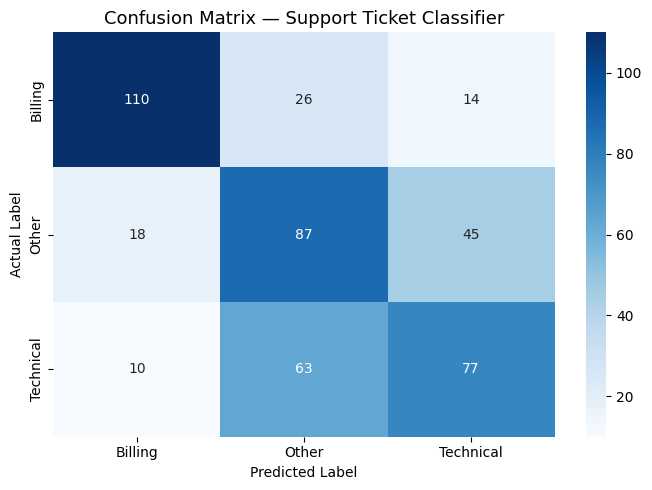

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_LIST, yticklabels=LABEL_LIST)
plt.title('Confusion Matrix — Support Ticket Classifier', fontsize=13)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Step 12 — Inference on New Tickets

In [17]:
device = 0 if torch.cuda.is_available() else -1

classifier = pipeline(
    task      = 'text-classification',
    model     = model,
    tokenizer = tokenizer,
    device    = device
)

new_tickets = [
    "Payment failed twice",
    "Cannot login to my account",
    "Package arrived damaged",
    "Refund is still pending after 2 weeks",
    "My delivery is delayed by 5 days",
    "App keeps crashing on startup",
    "I was charged twice for the same order",
    "Where is my shipment?",
    "Reset password link not working",
    "Invoice shows wrong amount"
]

print(f"{'Ticket':<45} {'Predicted Label':<12} {'Confidence':>10}")
print("-" * 72)

results = classifier(new_tickets)
for ticket, result in zip(new_tickets, results):
    print(f"{ticket:<45} {result['label']:<12} {result['score']:>10.2%}")

Ticket                                        Predicted Label Confidence
------------------------------------------------------------------------
Payment failed twice                          Billing          98.20%
Cannot login to my account                    Billing          85.18%
Package arrived damaged                       Technical        61.72%
Refund is still pending after 2 weeks         Billing          96.94%
My delivery is delayed by 5 days              Technical        51.01%
App keeps crashing on startup                 Other            48.77%
I was charged twice for the same order        Billing          87.93%
Where is my shipment?                         Other            35.76%
Reset password link not working               Other            44.09%
Invoice shows wrong amount                    Billing          98.80%


# Step 13 — Save the Model

In [18]:
SAVE_DIR = './support_ticket_classifier_final'

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f" Model saved to '{SAVE_DIR}'")
print("   Reload with:")
print(f"   AutoModelForSequenceClassification.from_pretrained('{SAVE_DIR}')")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Model saved to './support_ticket_classifier_final'
   Reload with:
   AutoModelForSequenceClassification.from_pretrained('./support_ticket_classifier_final')


# Step 14 — (Optional) Reload Saved Model & Predict

In [19]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

loaded_model     = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)
loaded_tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)

clf2 = pipeline('text-classification',
                model=loaded_model,
                tokenizer=loaded_tokenizer,
                device=device)

ticket = "My order has not arrived and it has been 10 days"
out    = clf2(ticket)[0]
print(f"Ticket  : {ticket}")
print(f"Category: {out['label']}  (confidence: {out['score']:.2%})")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Ticket  : My order has not arrived and it has been 10 days
Category: Other  (confidence: 41.57%)
